# scRITMO: Circadian Phase Inference Tutorial

This notebook demonstrates how to use the `scritmo` package to infer single-cell circadian phases from scRNA-seq data.

The method fits a **negative binomial gene expression model** with a circadian component, inferring a posterior distribution over the phase (time-of-day) for each cell, using core clock gene expression as a signature.

---
**Pipeline overview:**
1. Load data
2. Define reference circadian gene parameters
3. Train the model
4. Inspect inferred phases
5. Examine gene-level parameter shifts
6. Quantify biological desynchrony

In [1]:
import os
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt

import scritmo as sr
from scritmo import rh
import scritmo.ml as cr
from scritmo.ml.analysis_utils import append_first_timepoint_periodic

%load_ext autoreload
%autoreload 2


## 1. Load Data

We load a pre-processed AnnData object. The key observation column is `ZTmod`, which stores the **external (known) clock time** in hours (0–24). This acts as the ground-truth phase label and is used during training to compute prediction error.

The raw count matrix must be available as a layer named `spliced`.

In [2]:
data_path = "/home/maxine/Documents/andrea/context_repo/data/SKIN/concatenated.h5ad"
CT = "Fibroblast"

adata = sc.read_h5ad(data_path)
adata.layers["spliced"] = adata.X.copy()

In [3]:
adata

AnnData object with n_obs × n_vars = 13523 × 24027
    obs: 'n_counts', 'sample_name', 'ZT', 'ZTmod', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 's_counts', 'u_counts', 'percent_unspliced', 'organ', 'celltype', 'celltype_organ'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'log1p'
    layers: 'ambiguous', 's_log', 's_norm', 'spliced', 'u_log', 'u_norm', 'unspliced'

## 2. Gene Parameters

`scritmo` uses a `Beta` table that encodes the expected circadian expression profile of **core clock genes**. Each row is a gene; the key columns are:

| Column | Meaning |
|--------|------------------------------------------|
| `a_0` | Log-mesor (baseline expression, log space) |
| `a_1`, `b_1` | Fourier cosine/sine coefficients |
| `amp` | Amplitude of the oscillation |
| `phase` | Phase (peak time) in radians |

Here we use the built-in canonical circadian gene set (CCGs).

In [4]:
params_g = cr.get_ccg_pars()

# convert external clock time from hours to radians
true_phase = adata.obs.ZTmod.values * 2 * np.pi / 24

params_g

,a_0,a_1,b_1,phase,amp,log2fc,log10_mean,disp
Bhlhe40,-10.039983,-0.168747,0.041074,2.902832,0.173673,0.501115,-4.360309,0.071415
Bhlhe41,-9.289599,-0.427272,0.358016,2.444159,0.557438,1.608426,-4.034422,0.071415
Bmal1,-12.275592,1.372668,-0.523622,5.918761,1.469148,4.239066,-5.331222,0.071415
Ciart,-10.237618,-1.192793,0.346538,2.858849,1.242113,3.583980,-4.446141,0.071415
Clock,-10.968863,0.320745,-0.065373,6.082123,0.327340,0.944502,-4.763716,0.071415
Cry1,-11.691333,-0.007351,-0.584934,4.699823,0.584980,1.687897,-5.077481,0.071415
Dbp,-8.881467,-1.285762,1.063675,2.450442,1.668709,4.814876,-3.857172,0.071415
Npas2,-14.378429,1.468749,-0.242097,6.119822,1.488568,4.295100,-6.244473,0.071415
Nr1d1,-8.387754,-0.457018,1.437220,1.878672,1.508133,4.351553,-3.642755,0.071415
Nr1d2,-10.921415,-0.587953,0.511821,2.425310,0.779518,2.249215,-4.743110,0.071415


## 3. Model Training

We train a `ContextModel` using `warmup_and_train`. This jointly optimises per-cell phase posteriors and gene expression parameters via gradient descent.

Most arguments are left at their defaults (negative binomial likelihood, mesor warm-start from pseudobulk, `layer="spliced"`, ...). We only override the ones that matter for this dataset:
- `context=adata.obs.celltype` — per-cell group label, used later to group the desynchrony estimate by cell type
- `kill_amps=True` — keep gene amplitudes fixed to reference values to stabilise training
- `fix_phase=True` — use a fixed-phase warmup before the main optimisation
- `n_theta_post=100` — a smoother per-cell posterior, for nicer plots
- `true_phase` — external clock time in radians, used only to track MAE during training (not part of the loss)

The training plot shows the loss (left) and median absolute phase error in hours (right) over epochs.

Running in serial mode.



training model...


(<Figure size 1000x600 with 2 Axes>,
 <Axes: xlabel='Epoch', ylabel='Loss'>,
 <Axes: ylabel='Mean Absolute Deviation'>)

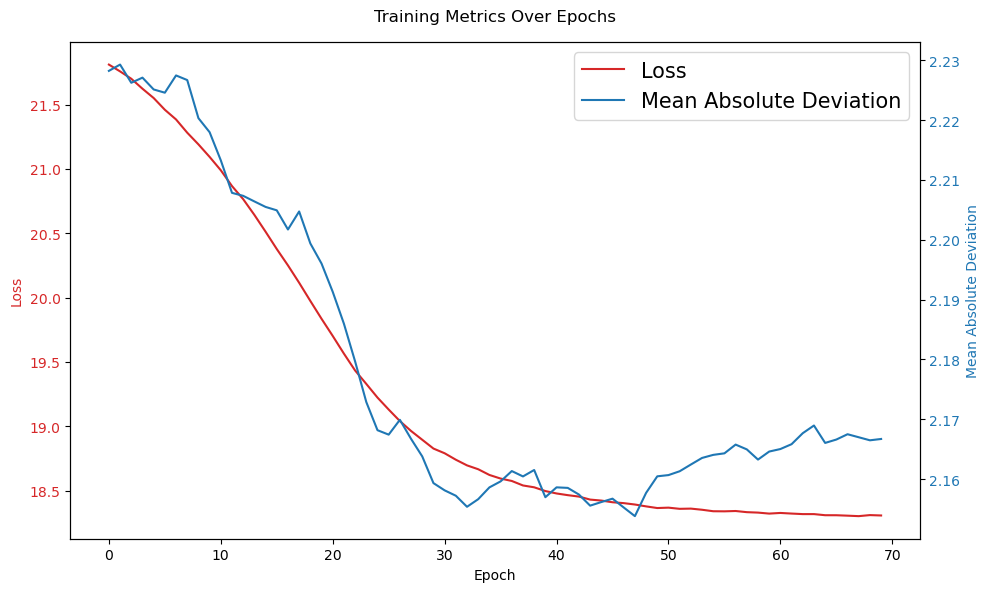

In [5]:
cmodel, losses, mad_epochs = cr.warmup_and_train(
    adata,
    params_g,
    context=adata.obs.celltype,
    fix_phase=True,
    batch_size=128,
    n_epochs=70,
    true_phase=true_phase,
    kill_amps=True,
    n_theta_post=100,
)
sr.plot_dual_loss(losses, mad_epochs)

## 4. Inferred Phases

After training, we extract per-cell phase estimates. `create_results_dataframe` collects the posterior mode (or mean) of each cell's phase distribution, together with external time and sample metadata.

We report the **Median Absolute Error (MAE)** in hours between inferred and external clock time as the main accuracy metric.

In [6]:
context_col = "celltype"

df_res = cmodel.create_results_df(
    adata,
    ext_phase=true_phase,
    context_col=context_col,
)
phi = df_res["pred_phase"]
best_mad = np.median(df_res["MAE"])
params_g_inf = cmodel.get_parameter_dataframe()

print(f"Median MAE: {best_mad:.2f} hours")

Created df_res. Median MAE: 2.08 hours
Median MAE: 2.08 hours


### Per-sample phase distributions

Each dot is a cell. The dashed horizontal lines show the external (ground-truth) ZT for each group. Good inference produces cell clouds centred on the corresponding dashed line.

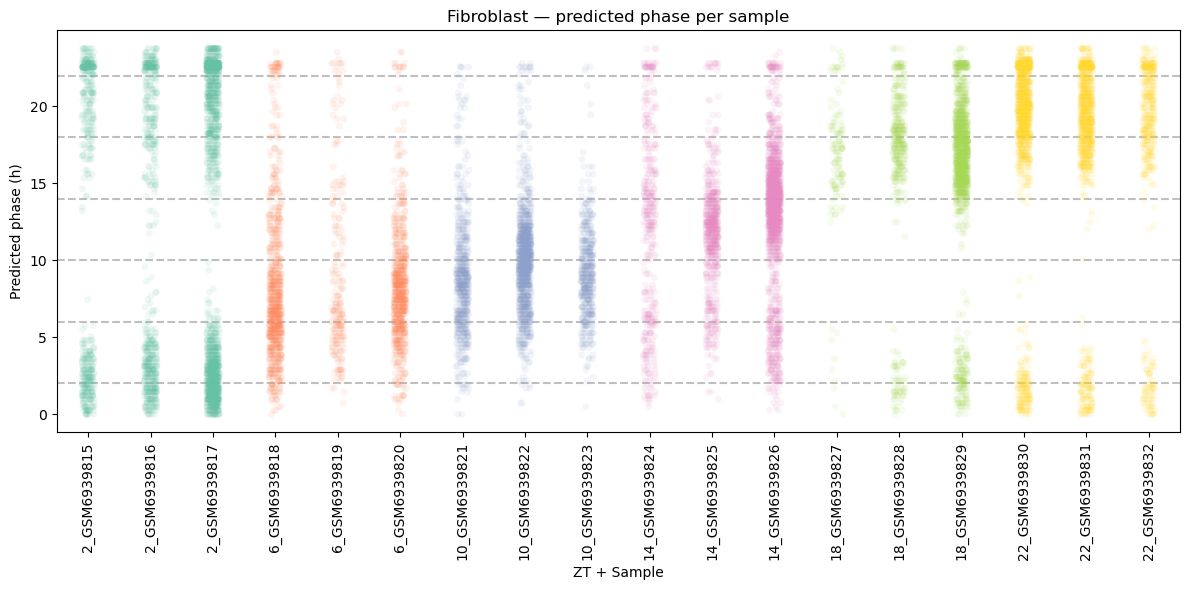

In [7]:
df_res["ZT_sample"] = (
    df_res["ext_time_hours"].astype(str) + "_" + df_res["sample_name"].astype(str)
)
plt.figure(figsize=(12, 6))
sns.stripplot(
    data=df_res,
    x="ZT_sample",
    y="pred_phase_h",
    hue="ext_time_hours",
    legend=False,
    alpha=0.1,
    palette="Set2",
)
plt.xticks(rotation=90)
for zt in df_res["ext_time_hours"].unique():
    plt.axhline(zt, color="gray", linestyle="--", alpha=0.5)
plt.xlabel("ZT + Sample")
plt.ylabel("Predicted phase (h)")
plt.title(f"{CT} — predicted phase per sample")
plt.tight_layout()
plt.show()

### Polar phase histogram

The rose plot shows the distribution of inferred phases (coloured by external time). A well-calibrated model produces arcs centred near the true ZT time points.

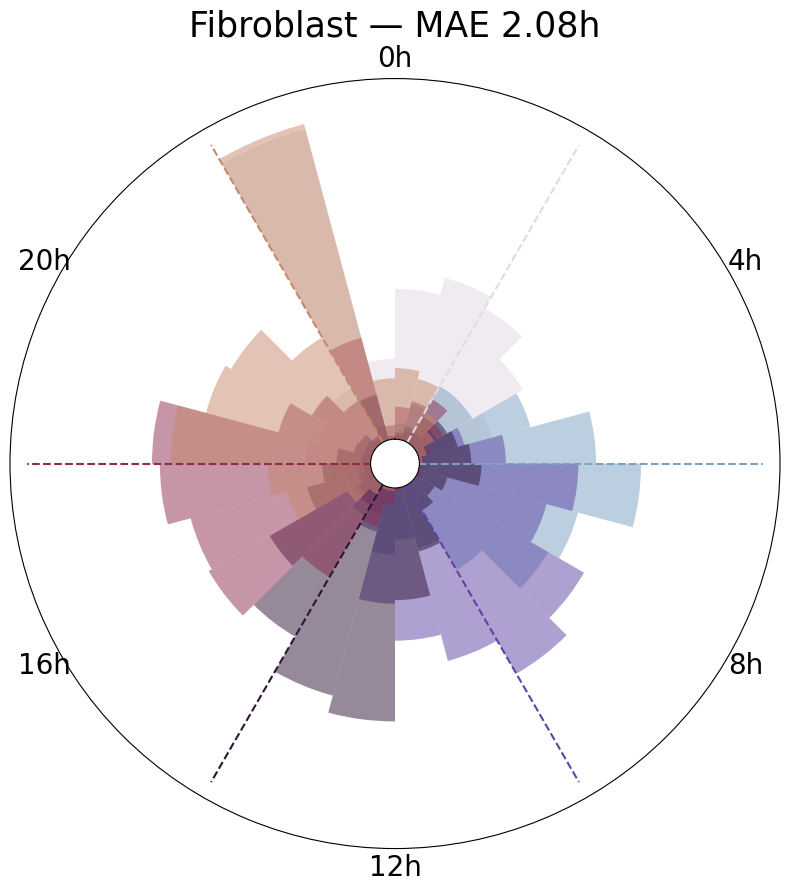

In [8]:
fig, ax = sr.plot_phase_polar_population(
    phases=phi,
    time=adata.obs["ZTmod"].values,
    show_grid=False,
    show_rlabels=False,
    bins=24,
    hist_density=True,
    inner_ring_size=0.2,
    show_legend=False,
)
ax.set_title(f"{CT} — MAE {best_mad:.2f}h", fontsize=25)
plt.show()

### True vs predicted phase scatter

Points along the diagonal indicate perfect phase recovery. Vertical spread at each ZT reflects within-sample variability.

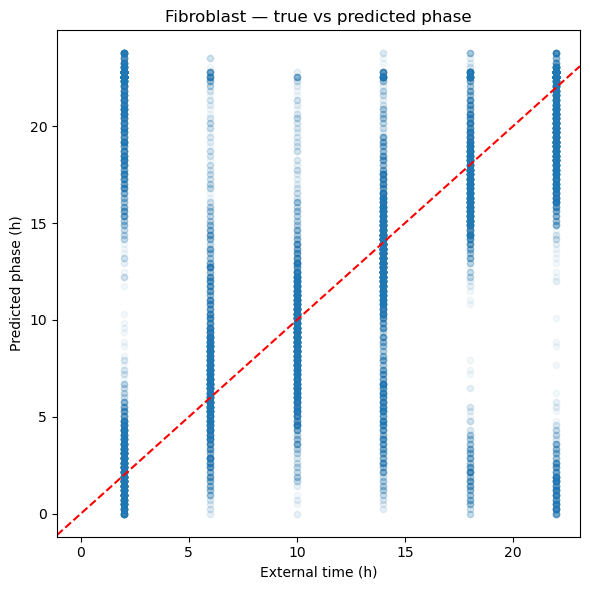

In [9]:
plt.figure(figsize=(6, 6))
plt.scatter(true_phase * rh, phi * rh, alpha=0.05, s=20)
sr.xy()
plt.xlabel("External time (h)")
plt.ylabel("Predicted phase (h)")
plt.title(f"{CT} — true vs predicted phase")
plt.tight_layout()
plt.show()

## 5. Gene-Level Analysis

The model updates gene parameters during training to better fit the data. Here we compare the **reference** (prior) parameters with the **trained** ones.

- The `a_0` scatter shows how baseline expression (log-mesor) shifted from reference to trained values.
- The beta-shift plot shows the change in amplitude and phase for each gene.

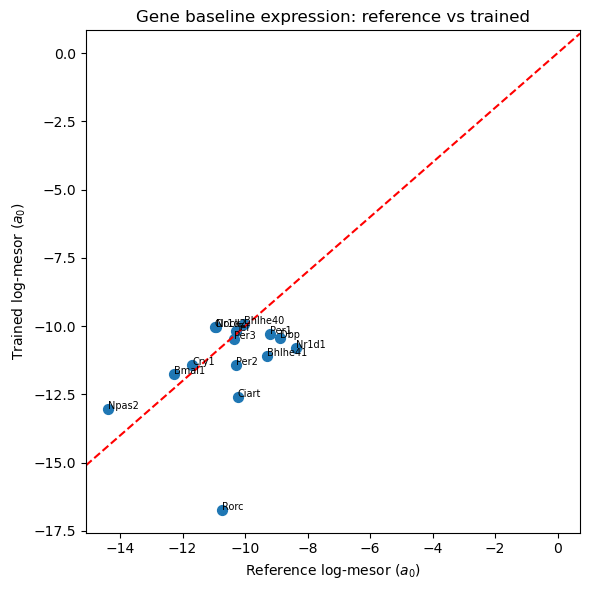

In [10]:
plt.figure(figsize=(6, 6))
plt.scatter(params_g.a_0, params_g_inf.a_0, s=50)
sr.xy()
for i, gene in enumerate(params_g_inf.index):
    plt.annotate(gene, (params_g.a_0.values[i], params_g_inf.a_0.values[i]), fontsize=7)
plt.xlabel("Reference log-mesor ($a_0$)")
plt.ylabel("Trained log-mesor ($a_0$)")
plt.title("Gene baseline expression: reference vs trained")
plt.tight_layout()
plt.show()

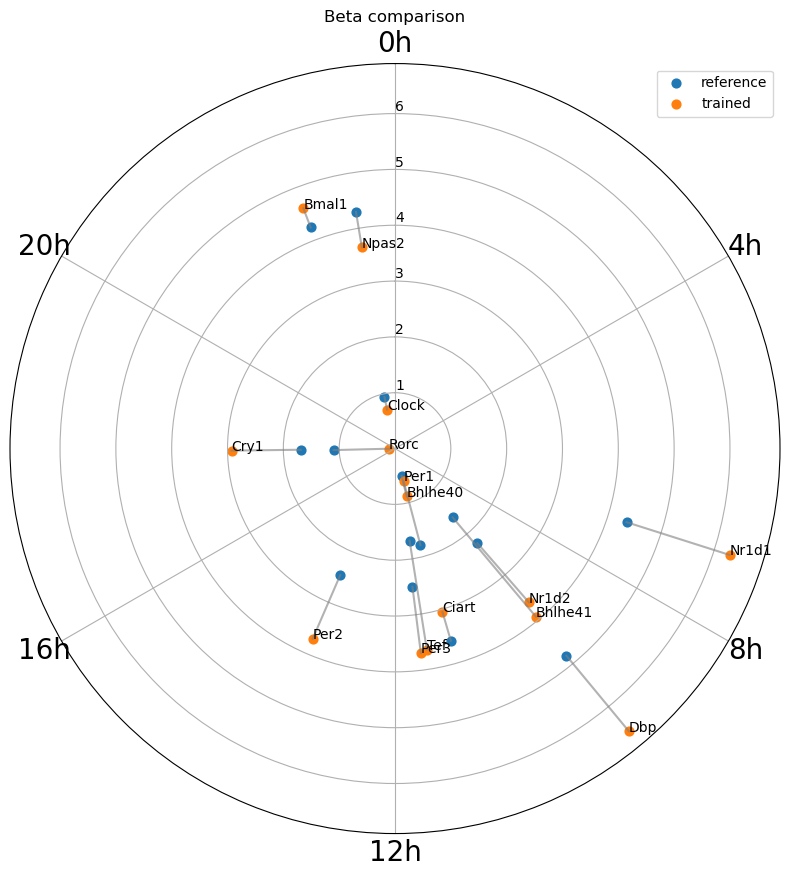

In [11]:
sr.beta.plot_beta_shift(params_g, params_g_inf, labels=["reference", "trained"])
plt.show()

## 6. Desynchrony Analysis

We quantify **biological desynchrony** — the spread of circadian phases within a population that is beyond what can be explained by measurement noise.

The approach:
1. **Simulate** fully synchronised populations using the trained model parameters → gives a *technical noise floor*.
2. **Compare** the phase spread in real data vs simulated data to isolate the biological component.

Three metrics (in hours, using circular standard deviation, cSTD):

| Metric | Meaning |
|--------|-------------------------------------------|
| $\sigma_{\text{Technical}}$ | Phase spread in synchronised simulated cells (noise floor) |
| $\sigma_{\text{Bio}}$ | Inferred biological phase spread |
| $\sigma_{\text{Data}}$ | Total observed spread ($\sigma_{\text{Data}}^2 \approx \sigma_{\text{Bio}}^2 + \sigma_{\text{Technical}}^2$) |

In [12]:
df_desync = cmodel.estimate_phase_desynchrony(
    adata,
    ext_phase=true_phase,
    context_col=context_col,
)

Created df_res. Median MAE: 2.08 hours
Simulating context: Fibroblast


Simulating context: Immune


### Summary desynchrony

`desync_means` computes a weighted average of each desynchrony component across time points, returning a single summary value per context.


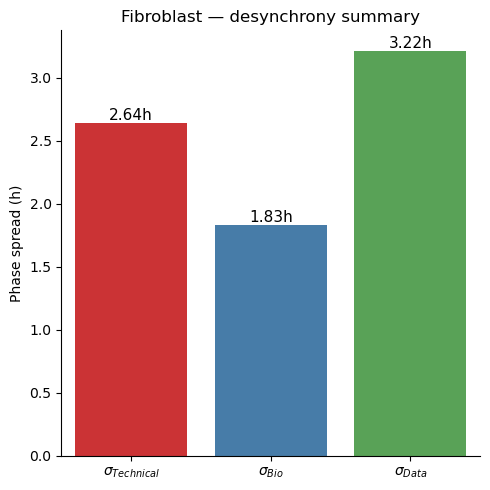

            Technical_cSTD  Bio_cSTD  Data_cSTD
ct                                             
Fibroblast        2.643730  1.829895   3.215249
Immune            2.958695  3.663155   4.708777


In [13]:
df_summary = cr.desync_means(df_desync)

bar_data = df_summary[["Technical_cSTD", "Bio_cSTD", "Data_cSTD"]].iloc[0]
bar_labels = [r"$\sigma_{Technical}$", r"$\sigma_{Bio}$", r"$\sigma_{Data}$"]

plt.figure(figsize=(5, 5))
ax = sns.barplot(
    x=bar_labels, y=bar_data.values, hue=bar_labels, palette="Set1", legend=False
)
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.2f}h",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=11,
    )
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.ylabel("Phase spread (h)")
plt.title(f"{CT} — desynchrony summary")
plt.tight_layout()
plt.show()

print(df_summary[["Technical_cSTD", "Bio_cSTD", "Data_cSTD"]].to_string())